In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pinxau1000/radioml2018/datasets.desktop
/kaggle/input/datasets/pinxau1000/radioml2018/classes-fixed.json
/kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5
/kaggle/input/datasets/pinxau1000/radioml2018/classes-fixed.txt
/kaggle/input/datasets/pinxau1000/radioml2018/LICENSE.TXT
/kaggle/input/datasets/pinxau1000/radioml2018/classes.txt


# Exploratory Data Analysis — RadioML 2018.01A

This notebook explores the RadioML 2018.01A dataset for the first time.
The goal is to understand what the dataset contains, what the arrays
represent, and what the signals look like — before writing any model code.

**Dataset:** RadioML 2018.01A (DeepSig)  
**Format:** HDF5  
**Task context:** LPD radar waveform generation (Ziemann & Metzler, 2024)

In [2]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# locate the dataset
HDF5_PATH = None
for dirpath, _, filenames in os.walk("/kaggle/input"):
    for fname in filenames:
        full = os.path.join(dirpath, fname)
        size_gb = os.path.getsize(full) / 1e9
        print(f"{full}  ({size_gb:.2f} GB)")
        if fname.endswith(".hdf5") or fname.endswith(".h5"):
            HDF5_PATH = full

print(f"\nUsing: {HDF5_PATH}")

/kaggle/input/datasets/pinxau1000/radioml2018/datasets.desktop  (0.00 GB)
/kaggle/input/datasets/pinxau1000/radioml2018/classes-fixed.json  (0.00 GB)
/kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5  (21.45 GB)
/kaggle/input/datasets/pinxau1000/radioml2018/classes-fixed.txt  (0.00 GB)
/kaggle/input/datasets/pinxau1000/radioml2018/LICENSE.TXT  (0.00 GB)
/kaggle/input/datasets/pinxau1000/radioml2018/classes.txt  (0.00 GB)

Using: /kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5


## 1. What is inside the file?

Open the HDF5 file and inspect every dataset — its name, shape, dtype,
and estimated memory footprint.

In [3]:
with h5py.File(HDF5_PATH, "r") as f:
    print(f"Keys: {list(f.keys())}\n")
    for key in f.keys():
        ds   = f[key]
        size = ds.size * ds.dtype.itemsize / 1e6
        print(f"  {key}")
        print(f"    shape : {ds.shape}")
        print(f"    dtype : {ds.dtype}")
        print(f"    RAM   : {size:,.0f} MB")
        print()

Keys: ['X', 'Y', 'Z']

  X
    shape : (2555904, 1024, 2)
    dtype : float32
    RAM   : 20,938 MB

  Y
    shape : (2555904, 24)
    dtype : int64
    RAM   : 491 MB

  Z
    shape : (2555904, 1)
    dtype : int64
    RAM   : 20 MB



## 2. What do the arrays contain?

Peek at the first and last few rows of each array to understand
how the data is ordered and what values look like.

In [4]:
with h5py.File(HDF5_PATH, "r") as f:
    for key in f.keys():
        print(f"── {key}")
        print(f"  first 3 rows:\n{f[key][:3]}")
        print(f"  last  3 rows:\n{f[key][-3:]}")
        print()

── X
  first 3 rows:
[[[ 0.0420274   0.23476323]
  [-0.2728826   0.40513492]
  [-0.26707262  0.22749889]
  ...
  [-0.7055947  -0.28693035]
  [-0.41157472  0.66826206]
  [ 0.06487698  0.6358149 ]]

 [[ 1.198624    0.4493616 ]
  [ 0.48543093  0.28272954]
  [ 0.8679219  -0.33194578]
  ...
  [-1.2129315  -0.64293194]
  [-0.38100415  0.793629  ]
  [ 0.0864124   1.0921808 ]]

 [[-0.22345497  0.18144214]
  [ 0.06201788 -0.934319  ]
  [ 0.71949023  0.21791682]
  ...
  [ 0.7598529   0.00820714]
  [ 0.3396765   0.12928951]
  [ 0.58232504  0.10775959]]]
  last  3 rows:
[[[ 8.1444943e-01  5.5400616e-01]
  [ 6.5612161e-01  4.9148661e-01]
  [ 4.4301039e-01  3.7589973e-01]
  ...
  [-1.1088575e-02 -8.8222519e-02]
  [ 3.0870318e-01 -1.3081287e-01]
  [ 6.2082106e-01 -1.6009325e-01]]

 [[-9.3082386e-01 -7.1716619e-01]
  [-9.5760763e-01 -8.7837487e-01]
  [-9.0744621e-01 -1.0274780e+00]
  ...
  [-1.8434896e-01 -8.1024897e-01]
  [-1.1144851e-01 -6.2748224e-01]
  [ 9.1281254e-04 -4.4244641e-01]]

 [[-1.05299

## 3. Load the small arrays

`Y` (labels) and `Z` (SNR) are small enough to load fully into RAM.  
`X` (signals) is ~21 GB — we never load it all at once.  
We load `Y` and `Z` now so we can understand the dataset's structure.

In [5]:
with h5py.File(HDF5_PATH, "r") as f:
    # Y is one-hot — convert to integer class index
    Y = np.argmax(f["Y"][:], axis=1)   # (N,)
    Z = f["Z"][:, 0]                   # (N,)  SNR in dB

print(f"Y shape : {Y.shape}  unique classes : {np.unique(Y)}")
print(f"Z shape : {Z.shape}  unique SNRs    : {np.unique(Z)}")
print(f"\nTotal samples : {len(Y):,}")
print(f"Classes       : {len(np.unique(Y))}")
print(f"SNR range     : {Z.min()} to {Z.max()} dB")

Y shape : (2555904,)  unique classes : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Z shape : (2555904,)  unique SNRs    : [-20 -18 -16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14
  16  18  20  22  24  26  28  30]

Total samples : 2,555,904
Classes       : 24
SNR range     : -20 to 30 dB


## 4. Class and SNR balance

Check whether the dataset is balanced across modulation classes and SNR levels.
An unbalanced dataset would require special handling during training.

Samples per class : min=106,496  max=106,496  — balanced
Samples per SNR   : min=98,304  max=98,304  — balanced


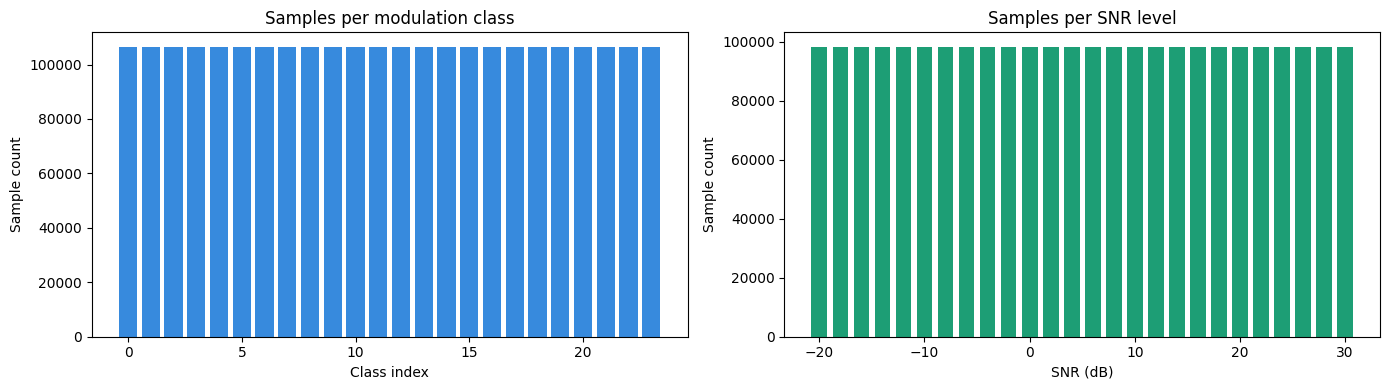

In [6]:
class_counts = [(Y == i).sum() for i in np.unique(Y)]
snr_counts   = [(Z == s).sum() for s in np.unique(Z)]

print(f"Samples per class : min={min(class_counts):,}  "
      f"max={max(class_counts):,}  "
      f"— {'balanced' if min(class_counts) == max(class_counts) else 'UNBALANCED'}")

print(f"Samples per SNR   : min={min(snr_counts):,}  "
      f"max={max(snr_counts):,}  "
      f"— {'balanced' if min(snr_counts) == max(snr_counts) else 'UNBALANCED'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(np.unique(Y), class_counts, color="#378ADD")
axes[0].set_xlabel("Class index")
axes[0].set_ylabel("Sample count")
axes[0].set_title("Samples per modulation class")

axes[1].bar(np.unique(Z), snr_counts, width=1.5, color="#1D9E75")
axes[1].set_xlabel("SNR (dB)")
axes[1].set_ylabel("Sample count")
axes[1].set_title("Samples per SNR level")

plt.tight_layout()
plt.savefig("eda_balance.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. What does one signal look like?

`X` stores IQ signals — each sample has two channels (I and Q) and
1024 time steps. We fetch a few rows directly by index to see what
the raw values look like before any processing.

Single sample shape : (1024, 2)  (time steps × IQ channels)
Value range         : -2.787  to  2.587
Mean / Std          : -0.0005  /  0.7107


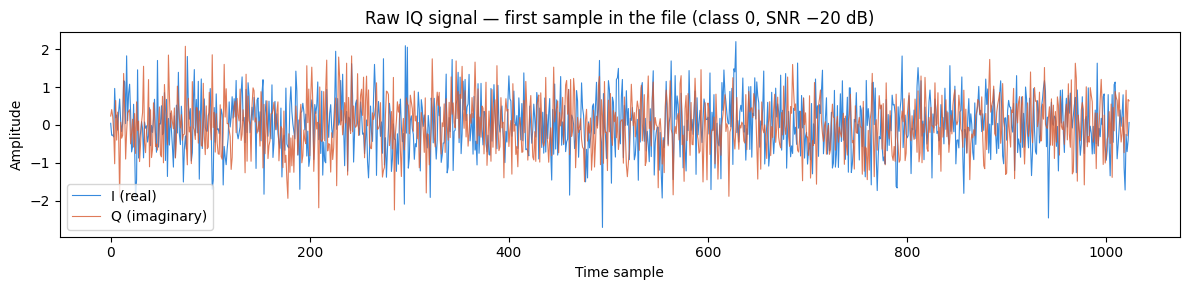

In [7]:
# fetch 3 rows from X without loading the whole array
with h5py.File(HDF5_PATH, "r") as f:
    x_peek = f["X"][:3]    # (3, 1024, 2)

print(f"Single sample shape : {x_peek[0].shape}  (time steps × IQ channels)")
print(f"Value range         : {x_peek.min():.3f}  to  {x_peek.max():.3f}")
print(f"Mean / Std          : {x_peek.mean():.4f}  /  {x_peek.std():.4f}")

# plot the I and Q channels of the first sample
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(x_peek[0, :, 0], linewidth=0.8, label="I (real)",      color="#378ADD")
ax.plot(x_peek[0, :, 1], linewidth=0.8, label="Q (imaginary)", color="#D85A30", alpha=0.8)
ax.set_xlabel("Time sample")
ax.set_ylabel("Amplitude")
ax.set_title("Raw IQ signal — first sample in the file (class 0, SNR −20 dB)")
ax.legend()
plt.tight_layout()
plt.savefig("eda_raw_signal.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Signals across classes and SNR levels

Now we look at how signals differ across modulation classes and SNR levels.  
We write a small helper to fetch samples for any (class, SNR) pair
without loading all of X.

Then we plot:
- The same class at different SNR levels — to see how noise affects the signal
- Different classes at the same SNR — to see how modulations differ

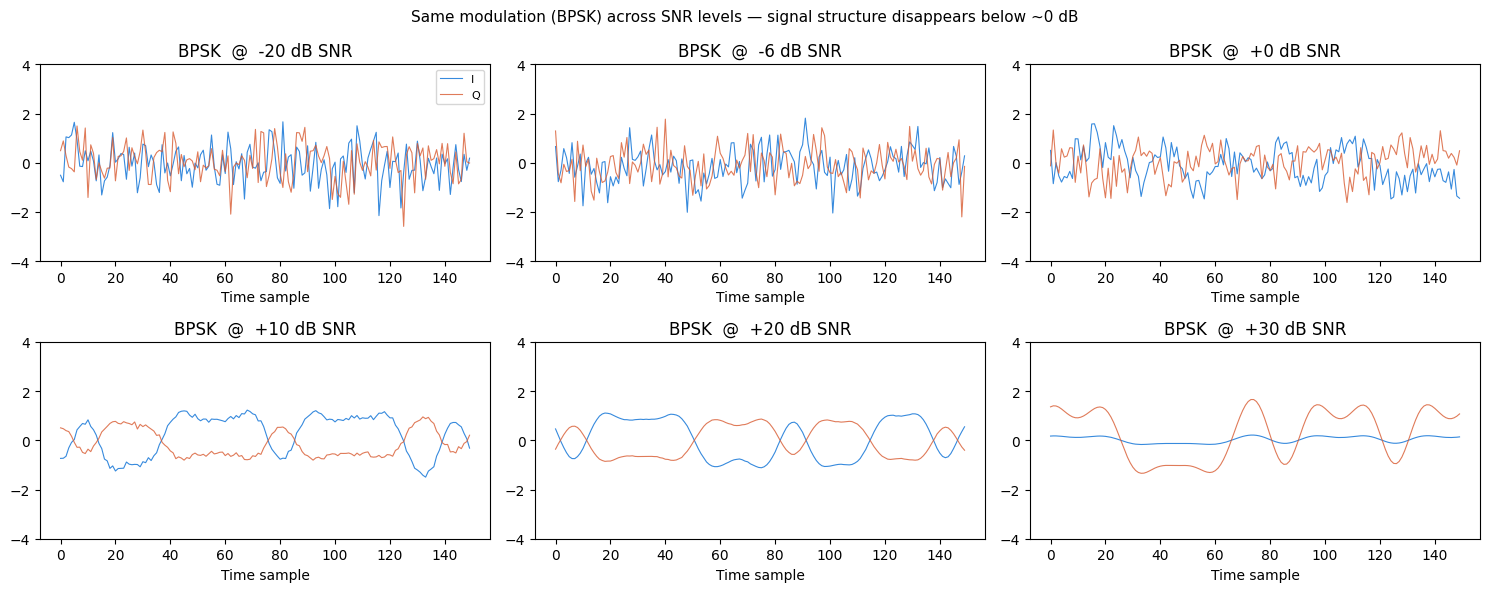

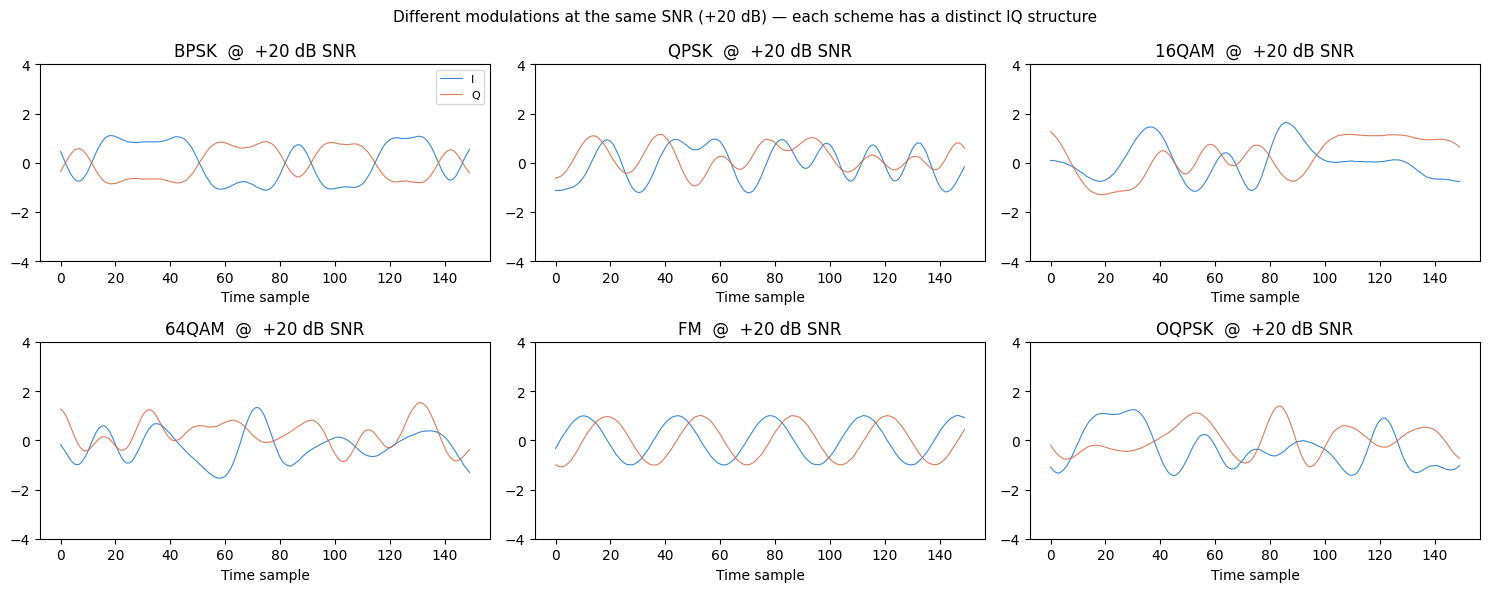

In [8]:
def fetch(class_idx, snr_db, n=1):
    """Fetch n samples for a given (class, SNR) pair. Returns (n, 1024, 2)."""
    rows = np.sort(np.where((Y == class_idx) & (Z == snr_db))[0][:n])
    with h5py.File(HDF5_PATH, "r") as f:
        return f["X"][rows]


# ── same class, different SNR ─────────────────────────────────────────────────
snrs    = [-20, -6, 0, 10, 20, 30]
fig, axes = plt.subplots(2, 3, figsize=(15, 6))

for ax, snr in zip(axes.flatten(), snrs):
    x = fetch(class_idx=3, snr_db=snr, n=1)[0]   # BPSK
    ax.plot(x[:150, 0], linewidth=0.8, color="#378ADD", label="I")
    ax.plot(x[:150, 1], linewidth=0.8, color="#D85A30", label="Q", alpha=0.8)
    ax.set_title(f"BPSK  @  {snr:+d} dB SNR")
    ax.set_ylim(-4, 4)
    ax.set_xlabel("Time sample")

axes[0, 0].legend(fontsize=8)
fig.suptitle("Same modulation (BPSK) across SNR levels — "
             "signal structure disappears below ~0 dB", fontsize=11)
plt.tight_layout()
plt.savefig("eda_snr_effect.png", dpi=120, bbox_inches="tight")
plt.show()


# ── different classes, same SNR ───────────────────────────────────────────────
# class indices and names for a representative selection
classes = [(3, "BPSK"), (4, "QPSK"), (12, "16QAM"),
           (14, "64QAM"), (21, "FM"), (23, "OQPSK")]

fig, axes = plt.subplots(2, 3, figsize=(15, 6))

for ax, (cidx, cname) in zip(axes.flatten(), classes):
    x = fetch(class_idx=cidx, snr_db=20, n=1)[0]
    ax.plot(x[:150, 0], linewidth=0.8, color="#378ADD", label="I")
    ax.plot(x[:150, 1], linewidth=0.8, color="#D85A30", label="Q", alpha=0.8)
    ax.set_title(f"{cname}  @  +20 dB SNR")
    ax.set_ylim(-4, 4)
    ax.set_xlabel("Time sample")

axes[0, 0].legend(fontsize=8)
fig.suptitle("Different modulations at the same SNR (+20 dB) — "
             "each scheme has a distinct IQ structure", fontsize=11)
plt.tight_layout()
plt.savefig("eda_class_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Constellation diagrams

Plot I on the x-axis and Q on the y-axis. Each time sample becomes a point.
This reveals the geometry of each modulation scheme at a glance.

Digital modulations produce discrete clusters (one per symbol).
Analog modulations produce continuous arcs or filled regions.

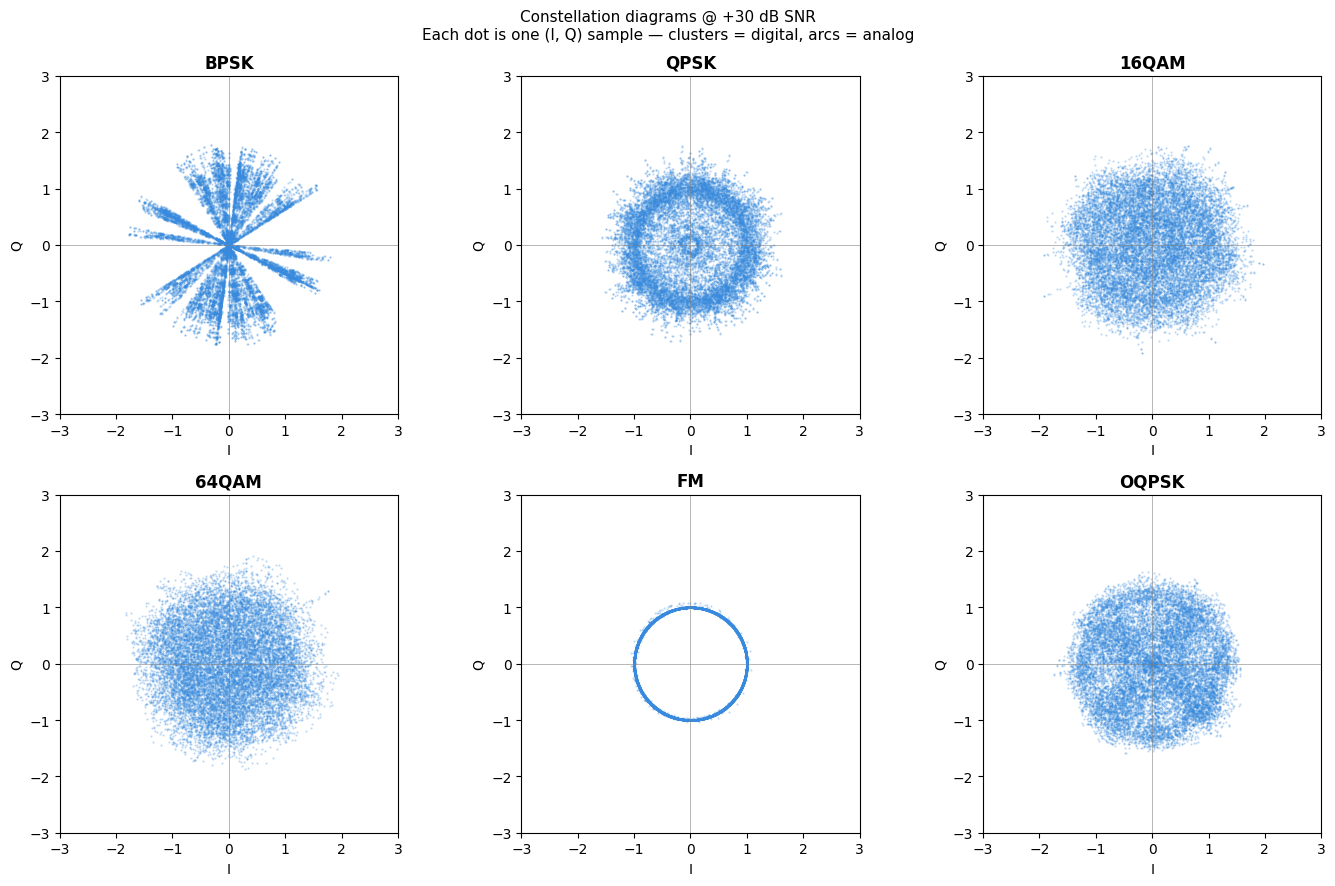

In [9]:
classes = [(3, "BPSK"), (4, "QPSK"), (12, "16QAM"),
           (14, "64QAM"), (21, "FM"), (23, "OQPSK")]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, (cidx, cname) in zip(axes.flatten(), classes):
    # use several samples at high SNR for a clean constellation
    x   = fetch(class_idx=cidx, snr_db=30, n=16)   # (16, 1024, 2)
    i_v = x[:, :, 0].ravel()
    q_v = x[:, :, 1].ravel()

    ax.scatter(i_v, q_v, s=0.3, alpha=0.3, color="#378ADD", rasterized=True)
    ax.axhline(0, color="gray", linewidth=0.4)
    ax.axvline(0, color="gray", linewidth=0.4)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")
    ax.set_title(cname, fontweight="bold")
    ax.set_xlabel("I")
    ax.set_ylabel("Q")

fig.suptitle("Constellation diagrams @ +30 dB SNR\n"
             "Each dot is one (I, Q) sample — "
             "clusters = digital, arcs = analog", fontsize=11)
plt.tight_layout()
plt.savefig("eda_constellations.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Key findings

| Property | Value | Training implication |
|----------|-------|----------------------|
| Total samples | 2,555,904 | Large — load X lazily, never fully |
| Classes | 24 modulations | Balanced — no weighting needed |
| SNR levels | −20 to +30 dB, step 2 | 26 levels, balanced |
| Samples per (class, SNR) | 4,096 | Consistent |
| X value range | approx ±17 | Per-sample normalisation required |
| File ordering | sorted by class, then SNR | Must shuffle in DataLoader |
| Signal structure at low SNR | Noise-dominated below ~0 dB | GAN task is easier at low SNR |
| Signal structure at high SNR | Clear modulation geometry | GAN must learn structure at high SNR |

**Next:** `02_data_pipeline.ipynb` — DataLoader, normalisation, train/test split.